<b><font color="#1f4e79" size="7">
Notebook 3:
<br></font></b>

<b><font color="#1f4e79" size="6">
Feature Selection & Dimensionality Reduction
</font></b>

<hr>



This notebook implements a complete pipeline for:

- Loading the connectivity feature matrices generated in Notebook 2.
- Applying **ANOVA (F-test)** for univariate feature selection.
- Applying **LASSO (L1 regularization)** for sparse feature selection.
- Applying **Principal Component Analysis (PCA)** for unsupervised dimensionality reduction.
- Comparing different feature selection and dimensionality reduction strategies through visualizations and summary statistics.

> **Note:** In this notebook, all methods are applied to the complete dataset for demonstration and visualization purposes. A proper training/testing workflow using cross-validation will be implemented in **Notebook 4**.

# Setup

## Install & Imports

In [2]:
import json
import zipfile
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif

!pip install -q mne mne_connectivity awscli
from mne.viz import circular_layout
from mne_connectivity.viz import plot_connectivity_circle

## Download Input Data

This section downloads all files required for feature selection and dimensionality reduction:

- Participant metadata (`participants.tsv`) from the original OpenNeuro dataset.
- Pearson connectivity feature matrix generated in **Notebook 2**.
- Partial connectivity feature matrix generated in **Notebook 2**.
- ROI metadata (AAL3 labels) generated in **Notebook 1** for mapping connectivity features back to anatomical brain regions.

In [3]:
!aws s3 cp s3://openneuro.org/ds002748/participants.tsv /content/participants.tsv --no-sign-request

# Pearson features matrix
!wget -O /content/X_pearson.npy \
"https://raw.githubusercontent.com/negareri/fMRI-Connectome-MDD/main/outputs/notebook2/X_pearson.npy"

# Partial features matrix
!wget -O /content/X_partial.npy \
"https://raw.githubusercontent.com/negareri/fMRI-Connectome-MDD/main/outputs/notebook2/X_partial.npy"

# ROI metadata (AAL3 labels)
!wget -O /content/AAL3_timeseries_all_subjects.zip \
"https://raw.githubusercontent.com/negareri/fMRI-Connectome-MDD/main/outputs/notebook1/AAL3_timeseries_all_subjects.zip"

with zipfile.ZipFile(
    "/content/AAL3_timeseries_all_subjects.zip"
) as z:
    z.extract(
        "extraction_metadata.json",
        "/content"
    )
Path("/content/AAL3_timeseries_all_subjects.zip").unlink()

download: s3://openneuro.org/ds002748/participants.tsv to ./participants.tsv
--2026-07-23 20:49:17--  https://raw.githubusercontent.com/negareri/fMRI-Connectome-MDD/main/outputs/notebook2/X_pearson.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7888448 (7.5M) [application/octet-stream]
Saving to: ‘/content/X_pearson.npy’

/content/X_pearson. 100%[===================>]   7.52M  --.-KB/s    in 0.07s   

2026-07-23 20:49:17 (106 MB/s) - ‘/content/X_pearson.npy’ saved [7888448/7888448]

--2026-07-23 20:49:17--  https://raw.githubusercontent.com/negareri/fMRI-Connectome-MDD/main/outputs/notebook2/X_partial.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubuser

## Participant Metadata

The participant metadata is loaded from the original OpenNeuro dataset.

This section provides a quick overview of the dataset, including the number of participants, available metadata columns, and the first few records.

In [4]:
participants = pd.read_csv("/content/participants.tsv", sep="\t")

print(f"Participants: {len(participants)}")
print(f"Columns: {participants.shape[1]}")

participants.head()

Participants: 72
Columns: 20


,participant_id,age,gender,group,IQ_Raven,ICD-10,MADRS,Zung_SDS,BDI,HADS-anx,HADS-depr,MC-SDS,TAS-26,ECR-avoid,ECR-anx,RRS-sum,RRS-reflection,RRS-brooding,RRS-depr,Edinburgh
0,sub-01,39,m,depr,113.0,F32.0,NaN,43.0,17.0,NaN,NaN,9.0,81.0,66.0,60.0,53.0,12.0,14.0,27.0,NaN
1,sub-02,50,m,depr,80.0,F32.0,NaN,47.0,10.0,NaN,NaN,15.0,54.0,62.0,78.0,59.0,14.0,12.0,33.0,NaN
2,sub-03,47,f,depr,87.0,F32.0,NaN,44.0,19.0,NaN,NaN,15.0,80.0,42.0,54.0,47.0,11.0,9.0,27.0,NaN
3,sub-04,32,f,depr,100.0,F32.0,NaN,34.0,6.0,NaN,NaN,10.0,71.0,42.0,39.0,37.0,9.0,9.0,19.0,NaN
4,sub-05,26,f,depr,104.0,F32.0,NaN,48.0,17.0,NaN,NaN,10.0,65.0,52.0,68.0,61.0,14.0,13.0,34.0,NaN


### Create Binary Class Labels

The participant table is first sorted by participant ID to match the order of the connectivity feature matrices.

A binary class label is then created from the original diagnostic group:

- **0** = Healthy Control (HC)
- **1** = Major Depressive Disorder (MDD)

The updated metadata table is saved for reuse in subsequent notebooks.

In [5]:
participants = participants.sort_values("participant_id")

participants["label"] = (
    participants["group"]
    .map({"control": 0, "depr": 1})
)

participants.to_csv(
    "/content/participants_with_labels.csv",
    index=False
)

print("Class distribution:")
print(participants["label"].value_counts())

participants.head()

Class distribution:
label
1    51
0    21
Name: count, dtype: int64


,participant_id,age,gender,group,IQ_Raven,ICD-10,MADRS,Zung_SDS,BDI,HADS-anx,...,MC-SDS,TAS-26,ECR-avoid,ECR-anx,RRS-sum,RRS-reflection,RRS-brooding,RRS-depr,Edinburgh,label
0,sub-01,39,m,depr,113.0,F32.0,NaN,43.0,17.0,NaN,...,9.0,81.0,66.0,60.0,53.0,12.0,14.0,27.0,NaN,1
1,sub-02,50,m,depr,80.0,F32.0,NaN,47.0,10.0,NaN,...,15.0,54.0,62.0,78.0,59.0,14.0,12.0,33.0,NaN,1
2,sub-03,47,f,depr,87.0,F32.0,NaN,44.0,19.0,NaN,...,15.0,80.0,42.0,54.0,47.0,11.0,9.0,27.0,NaN,1
3,sub-04,32,f,depr,100.0,F32.0,NaN,34.0,6.0,NaN,...,10.0,71.0,42.0,39.0,37.0,9.0,9.0,19.0,NaN,1
4,sub-05,26,f,depr,104.0,F32.0,NaN,48.0,17.0,NaN,...,10.0,65.0,52.0,68.0,61.0,14.0,13.0,34.0,NaN,1


## Load Features and Labels

The connectivity feature matrices are loaded, and the binary class labels are extracted from the participant metadata to create the target vector (`y`) for supervised analyses.

In [6]:
X_pearson = np.load("/content/X_pearson.npy")

X_partial = np.load("/content/X_partial.npy")

y = participants["label"].values

# Feature Mapping Utilities

The connectivity feature vectors generated in **Notebook 2** contain only numerical feature indices, making them difficult to interpret directly.

This section defines a set of helper functions to map connectivity features back to their corresponding ROI pairs and anatomical region names using the AAL3 atlas metadata. These utilities are used throughout the notebook to interpret and visualize the results of feature selection methods.

## Convert Feature Index to ROI Pair

This function converts a feature index from the upper triangular connectivity vector back to the corresponding pair of ROIs.

**Input**

- `feature_idx`: Index of the connectivity feature.
- `n_rois`: Total number of ROIs (default: 166).

**Output**

- `roi1`: Index of the first ROI.
- `roi2`: Index of the second ROI.

In [7]:
def feature_index_to_roi_pair(feature_idx, n_rois=166):

    triu_i, triu_j = np.triu_indices(n_rois, k=1)

    return triu_i[feature_idx], triu_j[feature_idx]

## Convert ROI Indices to Anatomical Region Names

This function maps two ROI indices to their corresponding anatomical region names using the AAL3 atlas metadata generated in **Notebook 1**.

**Input**

- `roi1`: Index of the first ROI.
- `roi2`: Index of the second ROI.

**Output**

- Name of the first ROI.
- Name of the second ROI.

In [8]:
with open("/content/extraction_metadata.json", "r") as f:
    metadata = json.load(f)

column_to_name = metadata["column_to_name"]

roi_names = [
    column_to_name[str(i)]
    for i in range(len(column_to_name))
]


def roi_pair_to_names(roi1, roi2):

    return roi_names[roi1], roi_names[roi2]

### Verify ROI Mapping

The following example demonstrates how a connectivity feature index can be converted back to its corresponding ROI indices and anatomical region names.

In [9]:
roi1, roi2 = feature_index_to_roi_pair(0)
print(roi1)
print(roi2)

name1, name2 = roi_pair_to_names(roi1, roi2)

print(name1)
print(name2)

0
1
Precentral_L
Precentral_R


## Visualize Selected Functional Connections

This function visualizes the selected connectivity features as a circular brain connectivity graph.

Each selected feature is mapped back to its corresponding ROI pair, reconstructed into a connectivity matrix, and displayed using the AAL3 atlas labels.

**Input**

- `feature_indices`: Indices of the selected connectivity features.
- `scores`: Feature importance values (e.g., ANOVA F-scores or LASSO coefficients).
- `title`: Figure title.
- `top_n`: Number of strongest connections to display. If `None`, all selected connections are shown.
- `colormap`: Colormap used to represent feature importance (default:`RdBu_r`).

**Output**

- A circular connectivity plot highlighting the selected functional connections.

In [10]:
def plot_selected_features_circle(
    feature_indices,
    scores,
    title="Selected Functional Connections",
    top_n=None,
    colormap="RdBu_r"
):

    order = np.argsort(np.abs(scores))[::-1]

    if top_n is not None:
        order = order[:top_n]

    feature_indices = np.array(feature_indices)[order]
    scores = np.array(scores)[order]

    n_rois = len(roi_names)

    connectivity = np.full((n_rois, n_rois), np.nan)

    for feature_idx, score in zip(feature_indices, scores):

        roi1, roi2 = feature_index_to_roi_pair(feature_idx, n_rois)

        connectivity[roi1, roi2] = score
        connectivity[roi2, roi1] = score

    node_angles = circular_layout(roi_names, roi_names, start_pos=90)

    plot_connectivity_circle(
        connectivity,
        roi_names,
        node_angles=node_angles,
        title=title,
        colormap=colormap,
        colorbar=True,
        fontsize_names=8,
        facecolor="white",
        textcolor="black"
    )

    plt.show()

# Analysis of Variance (ANOVA)

ANOVA is a statistical method used for evaluating whether the mean value of a feature differs significantly between groups.

In this notebook, one-way ANOVA is applied as a **univariate feature selection method** to identify functional connectivity features that differ between Healthy Control (HC) and Major Depressive Disorder (MDD) groups.

For each connectivity feature, ANOVA compares the variance between groups with the variance within groups using the F-statistic:

$$
F = \frac{\text{Between-group variance}}{\text{Within-group variance}}
$$

F-score is always non-negative and a higher score indicates features with stronger group separation.


## ANOVA Feature Selection and Visualization

The function below applies one-way ANOVA as a feature selection method using `SelectKBest`.

For each connectivity feature, an F-score is calculated between the two diagnostic groups. The top `k` features with the highest scores are selected.

Since ANOVA F-scores are always positive, a sequential colormap `YlOrRd` is used to represent increasing feature importance values.

**Input**

- `X`: Feature matrix containing connectivity features.
- `y`: Binary class labels.
- `k`: Number of features to select (default: 100).
- `title`: Title of the connectivity plot.
- `top_n_plot`: Number of strongest selected connections to display. If `None`, all selected features are shown.
- `n_rois`: Number of ROIs in the atlas (default: 166).

**Output**

- `X_selected`: Reduced feature matrix containing only selected features.
- `selected_indices`: Original indices of selected connectivity features.
- `selected_scores`: ANOVA F-scores of the selected features.
- `selector`: Fitted `SelectKBest` object.

The selected features are mapped back to AAL3 regions and visualized as a circular connectivity plot.

In [11]:
def anova_feature_selection_and_plot(
    X,
    y,
    k=100,
    title="ANOVA Selected Connections",
    top_n_plot=None,
    n_rois=166
):

    selector = SelectKBest(score_func=f_classif, k=k)

    X_selected = selector.fit_transform(X, y)

    selected_indices = selector.get_support(indices=True)

    selected_scores = selector.scores_[selected_indices]

    print(f"Original features: {X.shape[1]}")

    print(f"Selected features: {X_selected.shape[1]}")

    plot_selected_features_circle(
        feature_indices=selected_indices,
        scores=selected_scores,
        title=title,
        top_n=top_n_plot,
        colormap="YlOrRd"
    )

    return (
        X_selected,
        selected_indices,
        selected_scores,
        selector
    )

## Display Top Selected Connections

The following function converts the selected connectivity features into a readable table.

Each feature index is mapped back to its corresponding pair of AAL3 brain regions, allowing the strongest connections identified by ANOVA to be inspected directly.

**Input**

- `feature_indices`: Indices of selected connectivity features.
- `scores`: Feature importance scores.
- `score_name`: Name of the score column in the output table.
- `top_n`: Number of top connections to display (default: 20).
- `n_rois`: Number of ROIs in the atlas (default: 166).

**Output**

- A pandas DataFrame containing:
  - Feature index
  - ROI 1 name
  - ROI 2 name
  - Feature score

In [12]:
def get_top_selected_connections(
    feature_indices,
    scores,
    score_name="Score",
    top_n=20,
    n_rois=166
):
    order = np.argsort(np.abs(scores))[::-1]

    feature_indices = np.array(feature_indices)[order]

    scores = np.array(scores)[order]

    rows = []

    for idx, score in zip(feature_indices[:top_n], scores[:top_n]):

        roi1, roi2 = feature_index_to_roi_pair(idx, n_rois)

        roi1_name, roi2_name = roi_pair_to_names(roi1, roi2)

        rows.append({
            "Feature index": idx,
            "ROI 1": roi1_name,
            "ROI 2": roi2_name,
            score_name: score
        })


    return pd.DataFrame(rows)

### ANOVA on Pearson Connectivity Features

> **Note:** The choice of `k = 100` is only for demonstration purposes in this notebook. In **Notebook 4**, the optimal number of selected features will be determined within a cross-validation pipeline to avoid data leakage.

Original features: 13695
Selected features: 100


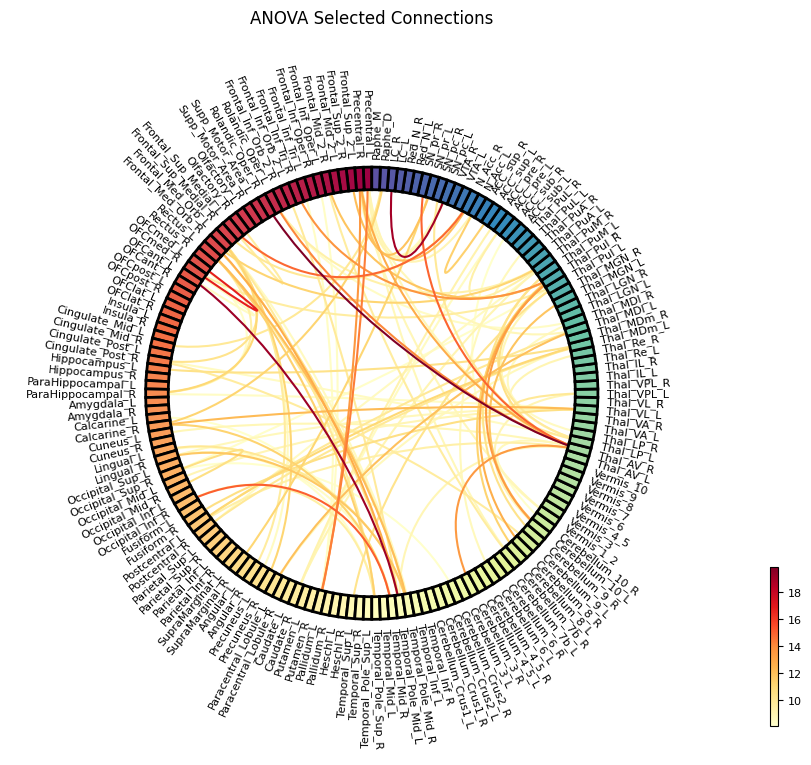

    Feature index                 ROI 1                ROI 2    F-score
0            2170       Rolandic_Oper_R            Thal_AV_R  19.831652
1            4024              OFCant_L  Temporal_Pole_Mid_L  19.130040
2           13656               SN_pc_L                 LC_R  18.951600
3            3684              OFCmed_L             OFCmed_R  16.782721
4            7619       Occipital_Inf_R       Temporal_Mid_R  15.071327
5           12560             Thal_AV_R              SN_pr_R  14.920503
6            2951  Frontal_Sup_Medial_L              N_Acc_R  14.816692
7              75          Precentral_L           Pallidum_L  14.307552
8            2018       Rolandic_Oper_L            Thal_AV_R  14.111258
9            1578     Frontal_Inf_Tri_R           Thal_PuI_R  13.696480
10            239          Precentral_R           Pallidum_L  13.582983
11          11231        Cerebellum_3_R            Thal_AV_R  13.442905
12          11957       Cerebellum_10_L           Thal_PuI_R  13

In [13]:
X_anova, anova_pearson_idx, anova_pearson_scores, selector = anova_feature_selection_and_plot(
    X_pearson,
    y,
    k=100,
)

top_connections_table = get_top_selected_connections(
    anova_pearson_idx,
    anova_pearson_scores,
    score_name="F-score",
    top_n=20
)

print(top_connections_table)

### ANOVA on Partial Connectivity Features

Original features: 13695
Selected features: 100


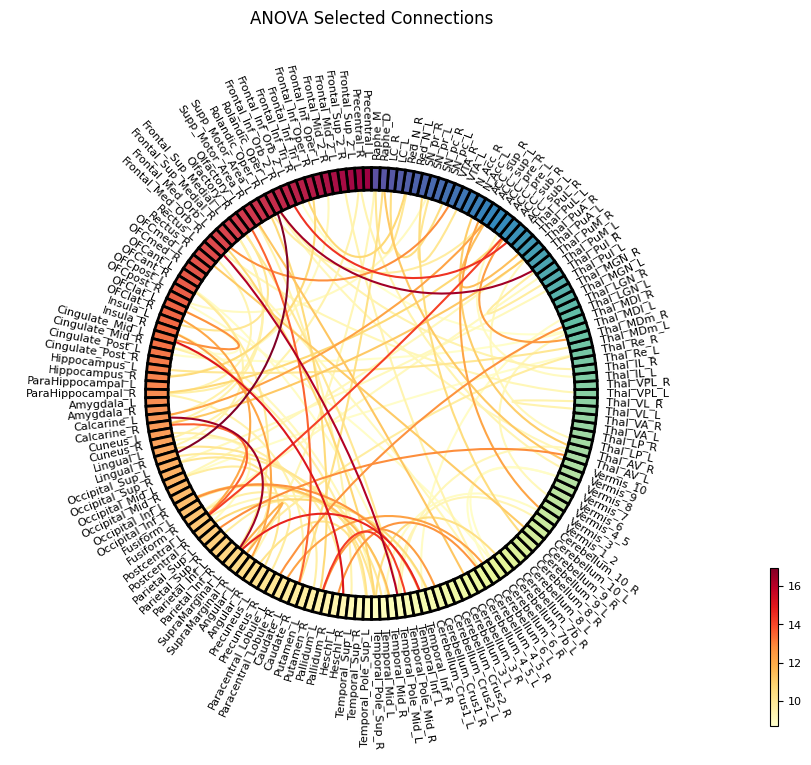

    Feature index                 ROI 1                ROI 2    F-score
0            1950       Rolandic_Oper_L            Lingual_R  16.955310
1            6333           Calcarine_L      SupraMarginal_L  16.415944
2            2042       Rolandic_Oper_L           Thal_PuM_R  16.365139
3            3319     Frontal_Med_Orb_R  Temporal_Pole_Mid_L  16.092983
4            5093       Cingulate_Mid_L             Heschl_R  15.056198
5            8568       SupraMarginal_L       Temporal_Inf_R  14.669779
6            1740   Frontal_Inf_Orb_2_L            ACC_sub_L  14.379289
7            9700            Pallidum_L  Temporal_Pole_Mid_R  14.169190
8            8005         Postcentral_L            ACC_sub_R  14.123868
9            6447           Calcarine_R        Postcentral_L  13.548802
10           2576           Olfactory_L            Caudate_R  13.515446
11           8185        Parietal_Sup_L            Thal_AV_L  12.799372
12           3244     Frontal_Med_Orb_L                VTA_R  12

In [14]:
X_anova, anova_partial_idx, anova_partial_scores, selector = anova_feature_selection_and_plot(
    X_partial,
    y,
    k=100,
)

top_connections_table = get_top_selected_connections(
    anova_partial_idx,
    anova_partial_scores,
    score_name="F-score",
    top_n=20
)

print(top_connections_table)

# Least Absolute Shrinkage and Selection Operator (LASSO)

LASSO is a supervised feature selection method that uses **L1 regularization** to identify the most informative features while simultaneously training a classification model.

Unlike ANOVA, which evaluates each feature independently, LASSO considers all features together and automatically removes less informative ones by shrinking their coefficients to exactly zero.

The objective function of LASSO logistic regression is:

$$
\min_{\beta} \left[ -\log L(\beta) + \lambda \sum_{j=1}^{p} |\beta_j|\right]
$$

Features with non-zero coefficients are selected, while those with zero coefficients are discarded.

## LASSO Feature Selection and Visualization

The function below performs feature selection using **L1-regularized logistic regression**.

After fitting the model, all features with non-zero coefficients are selected and visualized as functional connections.

**Input**

- `X`: Feature matrix containing connectivity features.
- `y`: Binary class labels.
- `C`: Inverse regularization strength. Larger values result in weaker regularization and typically select more features.
- `title`: Title of the connectivity plot.
- `top_n_plot`: Number of strongest selected connections to display. If `None`, all selected features are shown.
- `n_rois`: Number of ROIs in the atlas (default: 166).

**Output**

- `X_selected`: Reduced feature matrix containing only selected features.
- `selected_indices`: Original indices of selected connectivity features.
- `selected_coefficients`: LASSO coefficients of the selected features.
- `model`: Fitted logistic regression model.

Since LASSO coefficients can be positive or negative, the selected connections are visualized using the `RdBu_r` diverging colormap.

In [15]:
def lasso_feature_selection_and_plot(
    X,
    y,
    C=1,
    title="LASSO Selected Functional Connections",
    top_n_plot=None,
):

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    model = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=C,
        max_iter=5000,
        random_state=42
    )

    model.fit(X_scaled, y)

    coefficients = model.coef_[0]

    selected_indices = np.where(coefficients != 0)[0]

    selected_coefficients = coefficients[selected_indices]

    X_selected = X_scaled[:, selected_indices]

    print(f"Original features: {X.shape[1]}")

    print(f"Selected features: {len(selected_indices)}")


    if len(selected_indices) > 0:

        plot_selected_features_circle(
            feature_indices=selected_indices,
            scores=selected_coefficients,
            title=title,
            top_n=top_n_plot,
            colormap="RdBu_r"
        )

    else:
        print("No features selected. Try increasing C.")

    return (
        X_selected,
        selected_indices,
        selected_coefficients,
        model
    )

### LASSO on Pearson Connectivity Features

Since the class labels are encoded as **MDD = 1** and **HC = 0**:

- 🔴 **Positive coefficients:** Functional connections that are stronger in the MDD group.
- 🔵 **Negative coefficients:** Functional connections that are stronger in the HC group.

> **Note:** These fixed `C` values are used only for demonstration in this notebook. In **Notebook 4**, the optimal regularization strength will be determined within a cross-validation pipeline to avoid data leakage.

Original features: 13695
Selected features: 51


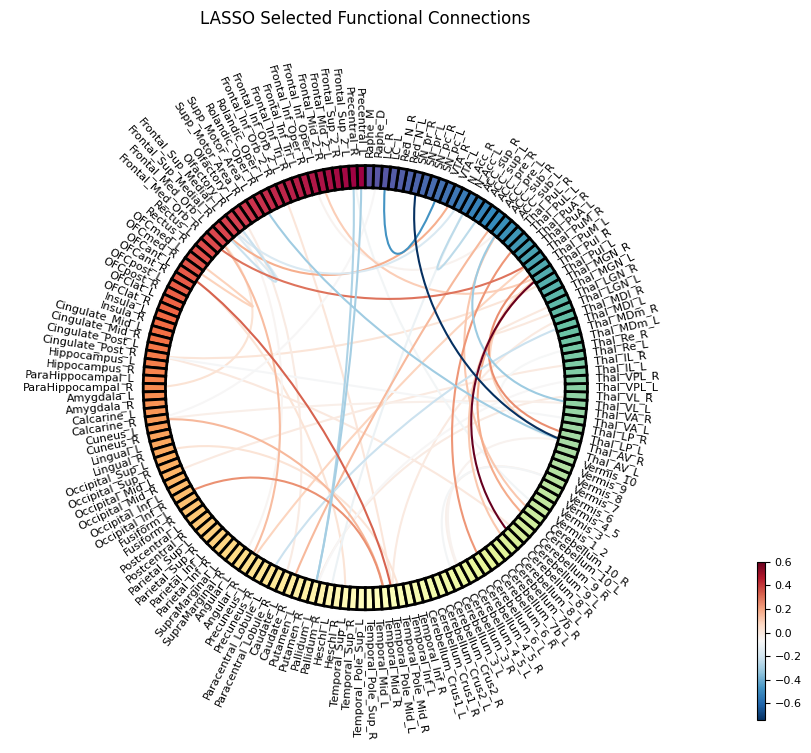

    Feature index                 ROI 1                 ROI 2     LASSO
0           12560             Thal_AV_R               SN_pr_R -0.743052
1           11777        Cerebellum_8_R            Thal_PuI_R  0.600123
2           13656               SN_pc_L                  LC_R -0.470687
3            4024              OFCant_L   Temporal_Pole_Mid_L  0.325887
4           12773             Thal_VL_L             ACC_sub_R -0.313505
5            2170       Rolandic_Oper_R             Thal_AV_R -0.310258
6              75          Precentral_L            Pallidum_L -0.300893
7            3374     Frontal_Med_Orb_R            Thal_PuM_R  0.291324
8             239          Precentral_R            Pallidum_L -0.278940
9           13576             ACC_sup_L               N_Acc_L -0.244851
10          12588             Thal_LP_L            Thal_PuM_L  0.242885
11           7619       Occipital_Inf_R        Temporal_Mid_R  0.234086
12          11462        Cerebellum_6_L            Thal_PuL_L  0

In [16]:
X_lasso, lasso_pearson_idx, lasso_pearson_scores, lasso_model = (
    lasso_feature_selection_and_plot(
        X_pearson,
        y,
        C=1,
        top_n_plot=None
    )
)

top_connections_table = get_top_selected_connections(
    lasso_pearson_idx,
    lasso_pearson_scores,
    score_name="LASSO",
    top_n=20
)

print(top_connections_table)

### LASSO on Partial Connectivity Features

Original features: 13695
Selected features: 62


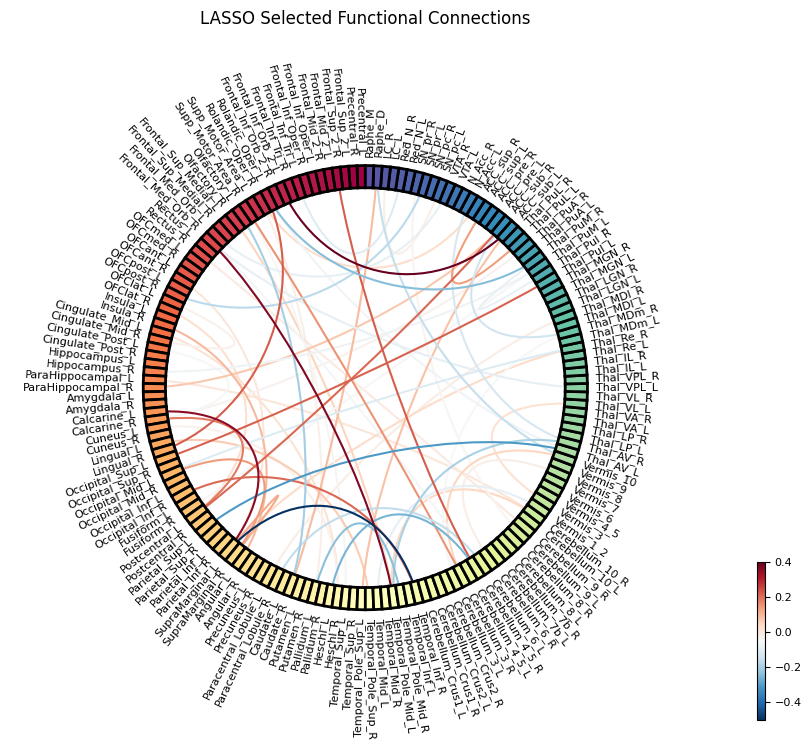

    Feature index                 ROI 1                ROI 2     LASSO
0            8568       SupraMarginal_L       Temporal_Inf_R -0.506441
1            1740   Frontal_Inf_Orb_2_L            ACC_sub_L  0.400054
2            3319     Frontal_Med_Orb_R  Temporal_Pole_Mid_L  0.369329
3            6333           Calcarine_L      SupraMarginal_L  0.351485
4            8185        Parietal_Sup_L            Thal_AV_L -0.313240
5            9885              Heschl_L     Cerebellum_4_5_R -0.265016
6            2042       Rolandic_Oper_L           Thal_PuM_R -0.245967
7            9700            Pallidum_L  Temporal_Pole_Mid_R -0.241317
8             585       Frontal_Sup_2_R     Cerebellum_4_5_R  0.222140
9            1950       Rolandic_Oper_L            Lingual_R  0.221371
10           7112       Occipital_Sup_L           Thal_PuI_L  0.213673
11           8005         Postcentral_L            ACC_sub_R  0.207671
12           2576           Olfactory_L            Caudate_R -0.206466
13    

In [17]:
X_lasso, lasso_partial_idx, lasso_partial_scores, lasso_model = (
    lasso_feature_selection_and_plot(
        X_partial,
        y,
        C=1,
        top_n_plot=None
    )
)

top_connections_table = get_top_selected_connections(
    lasso_partial_idx,
    lasso_partial_scores,
    score_name="LASSO",
    top_n=20
)

print(top_connections_table)

# Comparing Selected Features

Different feature selection methods may identify different subsets of functional connections.

The following function compares two sets of selected features.

**Input**

- `features_1`: Indices of the first feature set.
- `features_2`: Indices of the second feature set.
- `name_1`: Name of the first method.
- `name_2`: Name of the second method.

**Output**

- Prints a summary of the comparison.
- Returns the indices of the shared features.

In [18]:
def compare_selected_features(
    features_1,
    features_2,
    name_1="Method 1",
    name_2="Method 2"
):

    set_1 = set(features_1)
    set_2 = set(features_2)

    shared_features = set_1.intersection(set_2)

    print(f"{name_1}: {len(set_1)} features")
    print(f"{name_2}: {len(set_2)} features")
    print(f"Shared features: {len(shared_features)}")

    return shared_features

## ANOVA vs. LASSO

The overlap between the features selected by ANOVA and LASSO for the Pearson and partial connectivity matrices:

In [19]:
pearson_anova_lasso = compare_selected_features(
    anova_pearson_idx,
    lasso_pearson_idx,
    name_1="ANOVA Pearson",
    name_2="LASSO Pearson"
)

print("-----")

partial_anova_lasso = compare_selected_features(
    anova_partial_idx,
    lasso_partial_idx,
    name_1="ANOVA Partial",
    name_2="LASSO Partial"
)

ANOVA Pearson: 100 features
LASSO Pearson: 51 features
Shared features: 33
-----
ANOVA Partial: 100 features
LASSO Partial: 62 features
Shared features: 54


## Pearson vs. Partial Connectivity

The overlap between the selected features obtained from Pearson and partial connectivity matrices:

In [20]:
anova_pearson_partial = compare_selected_features(
    anova_pearson_idx,
    anova_partial_idx,
    name_1="ANOVA Pearson",
    name_2="ANOVA Partial"
)

print("-----")

lasso_pearson_partial = compare_selected_features(
    lasso_pearson_idx,
    lasso_partial_idx,
    name_1="LASSO Pearson",
    name_2="LASSO Partial"
)

ANOVA Pearson: 100 features
ANOVA Partial: 100 features
Shared features: 10
-----
LASSO Pearson: 51 features
LASSO Partial: 62 features
Shared features: 1


# Principal Component Analysis (PCA)

PCA is an **unsupervised dimensionality reduction** technique that transforms the original features into a new set of orthogonal variables called **principal components (PCs)**.

Unlike ANOVA and LASSO, PCA does **not** use the class labels (`y`). Instead, it identifies directions that capture the maximum variance in the data.

Each principal component is a linear combination of the original features, with the first components explaining the largest proportion of the total variance.

PCA projects the high-dimensional connectivity features into a lower-dimensional space while preserving as much information as possible. However, because each principal component combines many original features, the resulting representation is generally less interpretable than the features selected by ANOVA or LASSO.

## PCA Dimensionality Reduction

The function below applies PCA to the connectivity feature matrix.

Optionally, the features are standardized before PCA, since principal components are sensitive to the scale of the input variables.

**Input**

- `X`: Connectivity feature matrix.
- `n_components`: Number of principal components to retain, or the fraction of variance to preserve (e.g., `0.90`).
- `scale`: Whether to standardize the features before applying PCA.
- `scale`: If `True`, features are standardized using `StandardScaler` (zero mean, unit variance) before applying PCA.

**Output**

- `X_pca`: Reduced feature matrix in the principal component space.
- `pca`: Fitted PCA model.

The function also reports the original feature dimension, the reduced dimension, and the percentage of total variance explained by the retained principal components.

In [21]:
def run_pca(
    X,
    n_components=10,
    scale=True
):

    if scale:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = X

    pca = PCA(n_components=n_components, random_state=42)

    X_pca = pca.fit_transform(X_scaled)

    explained = pca.explained_variance_ratio_

    if isinstance(n_components, float):
        print(f"Original feature number: {X.shape[1]}")
        print(f"Reduced dimension: {X_pca.shape[1]}")
        print(f"{X_pca.shape[1]} principal components explain {explained.sum()*100:.2f}% of the total variance.")

    else:

        print(f"Original feature number: {X.shape[1]}")
        print(f"Reduced dimension: {X_pca.shape[1]}")
        print(f"Variance explained by the first {n_components} PCs: {explained.sum()*100:.2f}%")

    return X_pca, pca

## PCA Scatter Plot

The following function visualizes the first two principal components obtained from PCA.

Each point represents one participant projected onto the first two principal components, with colors indicating the corresponding diagnostic group. Although PCA is an unsupervised method and does not use the class labels during dimensionality reduction, the labels are used here only for visualization.

**Input**

- `X_pca`: Feature matrix projected into the PCA space.
- `y`: Binary class labels used for coloring the samples.
- `title`: Figure title.

**Output**

- A scatter plot of the first two principal components (PC1 vs. PC2).

In [22]:
def plot_pca_scatter(X_pca, y, title):

    plt.figure(figsize=(6,5))

    for label, name in [(0,"Control"),(1,"MDD")]:
        idx = y == label

        plt.scatter(
            X_pca[idx,0],
            X_pca[idx,1],
            label=name
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

### PCA on Pearson Connectivity Features

Rather than specifying a fixed number of principal components, `n_components = 0.99` is used to automatically retain the minimum number of components required to explain **99%** of the total variance.

The first two principal components are then visualized in a scatter plot to illustrate the distribution of participants in the reduced feature space.

> **Note:** This PCA analysis is performed on the full dataset for demonstration purposes. In **Notebook 4**, `StandardScaler` and PCA will be fitted only on the training data within a cross-validation pipeline to avoid data leakage.

Original feature number: 13695
Reduced dimension: 70
70 principal components explain 99.33% of the total variance.


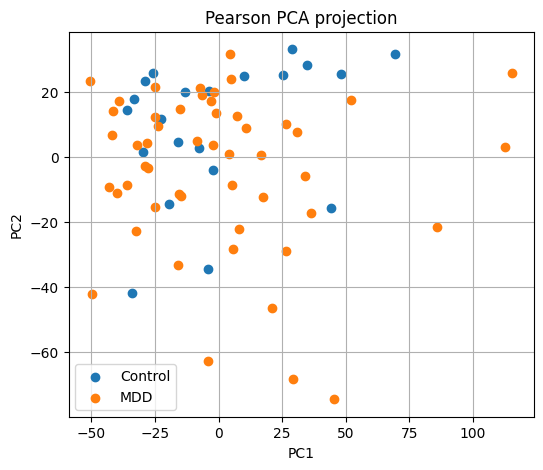

In [23]:
X_pca_pearson, pca_pearson = run_pca(
    X_pearson,
    n_components=0.99
)

plot_pca_scatter(
    X_pca_pearson,
    y,
    "Pearson PCA projection"
)

> **Note:**  
> PCA is an unsupervised dimensionality reduction method and does not use diagnostic labels during transformation. Therefore, the first two principal components are not expected to provide class separation. The scatter plot is only used to visualize the distribution of participants in the reduced feature space.

### PCA on Partial Connectivity Features

Original feature number: 13695
Reduced dimension: 71
71 principal components explain 100.00% of the total variance.


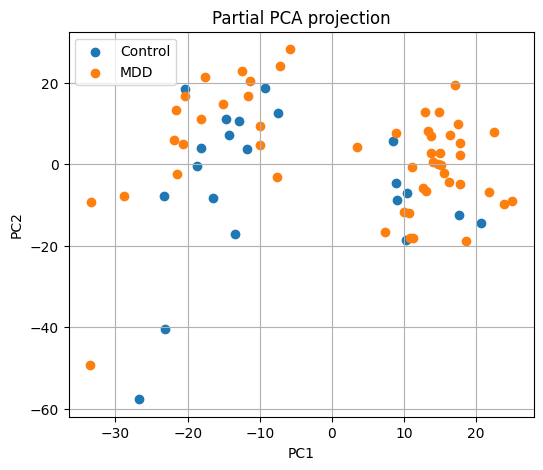

In [24]:
X_pca_partial, pca_partial = run_pca(
    X_partial,
    n_components=0.99
)

plot_pca_scatter(
    X_pca_partial,
    y,
    "Partial PCA projection"
)